# 03 — Volatility Forecasting (모델 구축·평가)

> Phase 1.5 LSTM v4 + HAR-RV 베이스라인 + Performance-Weighted Ensemble (Diebold-Pauly 1987) 의
> **재현 검증·평가 노트북**.

## 본 노트북의 역할

`final/phase3(data_outputs)/data/ensemble_predictions_stockwise.csv` (LSTM 학습 결과)를 입력으로 받아:
- §1 csv 정합성 검증 (snapshot 모드 / 재학습 후 모드 자동 분기)
- §2 LSTM v4 모델 구조·파라미터 카운트
- §3 HAR-RV 베이스라인 함수 시그니처
- §4 cache hit 모드로 학습 결과 로드 (재학습은 외부 노트북에서)
- §5 Performance-Weighted Ensemble 가중치 분포
- §6 615 종목 RMSE 분포 + 시각화
- §7 핵심 수치 검증 + summary.json 저장

## 재학습이 필요한 경우

본 노트북은 **학습 결과 검증·평가** 만 담당합니다. LSTM 자체를 재학습하려면:

```
시계열_Test/Phase3_Robust_Extensions/02a_retrain_2025_12.ipynb
```

이 노트북은 한 번 실행으로 다음을 모두 갱신합니다:
- `시계열_Test/.../daily_panel.csv` (target_logrv)
- `시계열_Test/.../fold_predictions_stockwise.csv` (LSTM)
- `final/phase3(data_outputs)/data/ensemble_predictions_stockwise.csv` (자동 복사)
- `final/results/*.pkl` 156개의 2025년 12 시점 (자동 재계산)

재학습 완료 후 본 03 노트북을 다시 실행하면 갱신된 ensemble csv 가 자동 검증됩니다.

## 모드

- **snapshot 모드** (default): csv md5 가 시계열_Test 5월 초 원본과 일치 → byte-byte 동등 검증
- **재학습 후 모드**: md5 다름 → 구조·범위 검증, RMSE 차이 표시 (참고용)

## §0. 환경 설정

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore', category=FutureWarning)

# timeseries_lib import
sys.path.insert(0, str(Path.cwd()))
import timeseries_lib as tlib

# 시드·폰트 고정
tlib.setup_seeds(42)
tlib.setup_korean_font()

# 경로
DATA_DIR = Path('phase3(data_outputs)/data')
PANEL_DIR = Path('data')
OUT_DIR = Path('outputs/03_volatility')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 캐시 모드
FORCE_RECOMPUTE = False  # True 시 615 종목 LSTM 재학습 (GPU + 3~5시간, Phase 1.5 모듈 필요)

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUT_DIR : {OUT_DIR.resolve()}")
print(f"FORCE_RECOMPUTE: {FORCE_RECOMPUTE}")

DATA_DIR: C:\Users\gorhk\최종 프로젝트\finance_project\final\phase3(data_outputs)\data
OUT_DIR : C:\Users\gorhk\최종 프로젝트\finance_project\final\outputs\03_volatility
FORCE_RECOMPUTE: False


## §1. CSV 데이터 정합성 검증 ⚠️

`final/phase3(data_outputs)/data/ensemble_predictions_stockwise.csv` 가 시계열_Test 원본과 정확히 일치하는지 검증합니다.

**검증 항목**:
1. md5 hash 일치 (시계열_Test 원본과 byte-byte 동일)
2. row / column / 종목 수 / 날짜 범위
3. y_true 의 -inf 행 제거 (거래정지 등)
4. 615 종목 stockwise 환경 RMSE 평균 (LSTM 0.43±, HAR 0.39±, Ensemble 0.38±)

In [2]:
import hashlib

CSV_PATH = DATA_DIR / 'ensemble_predictions_stockwise.csv'

# 1.1 md5 hash 검증 (snapshot vs post-retrain 자동 분기)
print("§1.1 md5 hash 검증")
print("-" * 60)
with open(CSV_PATH, 'rb') as f:
    md5 = hashlib.md5(f.read()).hexdigest()
print(f"current md5: {md5}")

# 시계열_Test 원본 (2026-05-01 빌드, 5월 초 panel cutoff) 의 md5
SNAPSHOT_MD5 = '1e9ab2faf63fdfd4abbb54083a1cb0fb'

# 02a_retrain_2025_12 노트북으로 재학습한 경우 md5 가 다름 — 정상
if md5 == SNAPSHOT_MD5:
    print(f"  ✓ snapshot 일치 (5월 초 원본) — byte-byte 동등")
    SNAPSHOT_MODE = True
else:
    print(f"  ⚠ snapshot 와 다름 (재학습/갱신된 csv)")
    print(f"     - snapshot md5 : {SNAPSHOT_MD5}")
    print(f"     - current md5  : {md5}")
    print(f"  → 재학습 후 갱신본 검증 모드로 진행 (구조·범위 검증, byte 비교 skip)")
    SNAPSHOT_MODE = False

§1.1 md5 hash 검증
------------------------------------------------------------


md5: 1e9ab2faf63fdfd4abbb54083a1cb0fb
  ✓ 시계열_Test 원본과 byte-byte 일치 (expected 1e9ab2faf63fdfd4abbb54083a1cb0fb)


In [3]:
# 1.2 데이터 로드 + 기본 정제 (-inf 제거)
print()
print("§1.2 데이터 로드")
print("-" * 60)
df = tlib.load_ensemble_predictions(CSV_PATH)

# 1.3 구조 검증
print()
print("§1.3 구조 검증")
print("-" * 60)
print(f"  shape: {df.shape}")
print(f"  columns: {list(df.columns)}")
print(f"  종목 수: {df['ticker'].nunique()}")
print(f"  date 범위: {df['date'].min().date()} ~ {df['date'].max().date()}")
print(f"  fold 수: {df['fold'].nunique()}")

# 종목 수 검증 — universe 확장 (615 → 619) 변동 허용
n_tickers = df['ticker'].nunique()
assert 600 <= n_tickers <= 625, f"종목 수 비정상: {n_tickers} (예상 600~625)"
assert {'date','ticker','fold','y_true','y_pred_lstm','y_pred_har',
        'w_v4','w_har','y_pred_ensemble'}.issubset(df.columns), "컬럼 누락"
if SNAPSHOT_MODE:
    assert n_tickers == 613, f"snapshot 모드: 종목 수 불일치 ({n_tickers} != 613)"
    print(f"  ✓ snapshot 일치: 613 종목")
else:
    print(f"  ✓ 재학습 후 모드: {n_tickers} 종목 (600~625 정상 범위)")

# 데이터 cover 검증 (2025-12 / 2026-04 등)
date_max = df['date'].max()
print(f"
  최신 학습 데이터: {date_max.date()}")
if SNAPSHOT_MODE:
    print(f"  → snapshot: 2025-12-01 (12월 1일치) 만 cover")
else:
    print(f"  → 재학습 후: 2025-12 ~ 2026-04 forward 21d 부재 직전까지 cover 가능")


§1.2 데이터 로드
------------------------------------------------------------


ensemble_predictions 로드: 2,468,883 → 2,468,770 행 (-inf/NaN 113 행 제거)

§1.3 구조 검증
------------------------------------------------------------
  shape: (2468770, 9)
  columns: ['date', 'ticker', 'fold', 'y_true', 'y_pred_lstm', 'y_pred_har', 'w_v4', 'w_har', 'y_pred_ensemble']
  종목 수: 613
  date 범위: 2007-04-23 ~ 2025-12-01
  fold 수: 224
  ✓ 구조 검증 통과


In [4]:
# 1.4 615 종목 평균 RMSE 검증 (Phase 3-2 §2-B 기준)
print()
print("§1.4 615 종목 평균 RMSE 검증")
print("-" * 60)
rmse_full = df.groupby('ticker', group_keys=False).apply(
    lambda x: pd.Series({
        'lstm': tlib.rmse(x['y_true'].values, x['y_pred_lstm'].values),
        'har': tlib.rmse(x['y_true'].values, x['y_pred_har'].values),
        'ens': tlib.rmse(x['y_true'].values, x['y_pred_ensemble'].values),
    }),
    include_groups=False,
)
print(f"  LSTM avg RMSE:     {rmse_full['lstm'].mean():.4f}")
print(f"  HAR  avg RMSE:     {rmse_full['har'].mean():.4f}")
print(f"  Ensemble avg RMSE: {rmse_full['ens'].mean():.4f}")
print()
print(f"  Best model 분포 (모델별 best 종목 수):")
best_per_ticker = rmse_full.idxmin(axis=1).value_counts()
for model, n in best_per_ticker.items():
    print(f"    {model}: {n} 종목 ({n/len(rmse_full)*100:.1f}%)")


§1.4 615 종목 평균 RMSE 검증
------------------------------------------------------------


  LSTM avg RMSE:     0.5288
  HAR  avg RMSE:     0.4015
  Ensemble avg RMSE: 0.3910

  Best model 분포 (모델별 best 종목 수):
    ens: 398 종목 (64.9%)
    har: 199 종목 (32.5%)
    lstm: 16 종목 (2.6%)


In [5]:
# 1.5 Universe 호환성 (final/data/universe.csv 와 교집합)
print()
print("§1.5 Universe 호환성")
print("-" * 60)
universe = pd.read_csv(PANEL_DIR / 'universe.csv')
print(f"  final/universe.csv 종목 수: {universe['ticker'].nunique()}")
ens_tickers = set(df['ticker'].unique())
uni_tickers = set(universe['ticker'].unique())
print(f"  ensemble 종목 수: {len(ens_tickers)}")
print(f"  교집합: {len(ens_tickers & uni_tickers)}")
assert ens_tickers.issubset(uni_tickers), "ensemble 종목이 final universe 에 부분집합 아님"
print("  ✓ ensemble 613 종목 ⊂ final universe 833 (완벽 부분집합)")


§1.5 Universe 호환성
------------------------------------------------------------
  final/universe.csv 종목 수: 833
  ensemble 종목 수: 613
  교집합: 613
  ✓ ensemble 613 종목 ⊂ final universe 833 (완벽 부분집합)


## §2. LSTM v4 모델 구축

Phase 1.5 v4 best 아키텍처 (3ch_vix / IS=1250 / hidden=32 / dropout=0.3) 를 정의합니다.
파라미터 수 ≈ 4,769 (입력 3채널 기준).

In [6]:
# §2.1 모델 인스턴스 + 파라미터 카운트
print("§2.1 LSTM v4 best 아키텍처")
print("-" * 60)
model = tlib.LSTMRegressor(input_size=3, hidden_size=32, num_layers=1, dropout=0.3)
n_params = tlib.count_parameters(model)
print(model)
print(f"\nParameter count: {n_params:,}")
assert 4500 < n_params < 5000, f"parameter count 비정상: {n_params}"
print(f"  ✓ 예상 범위 4,500~5,000 충족")

§2.1 LSTM v4 best 아키텍처
------------------------------------------------------------
LSTMRegressor(
  (lstm): LSTM(3, 32, batch_first=True)
  (head_dropout): Dropout(p=0.3, inplace=False)
  (head): Linear(in_features=32, out_features=1, bias=True)
)

Parameter count: 4,769
  ✓ 예상 범위 4,500~5,000 충족


## §3. HAR-RV 베이스라인 (Corsi 2009)

```
log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])
```

Heterogeneous Market Hypothesis (Müller et al. 1997) 의 일별·주별·월별 다중 시간대 평균.
Walk-Forward 환경에서 train_idx 만으로 OLS 적합.

In [7]:
# §3.1 HAR-RV 함수 시그니처 확인
print("§3.1 HAR-RV — fit_har_rv 시그니처")
print("-" * 60)
help(tlib.fit_har_rv)

§3.1 HAR-RV — fit_har_rv 시그니처
------------------------------------------------------------
Help on function fit_har_rv in module timeseries_lib:

fit_har_rv(log_ret: 'pd.Series', train_idx: 'np.ndarray', test_idx: 'np.ndarray', horizon: 'int' = 21, eps: 'float' = 1e-12) -> 'Tuple[np.ndarray, Dict[str, float]]'
    HAR-RV (Heterogeneous Autoregressive Realized Volatility).
    
    log(RV_h[t+h]) = β₀ + β_d·log(RV_d[t]) + β_w·log(RV_w[t]) + β_m·log(RV_m[t])
    
    Variance proxy (일간 데이터 적응):
        RV_var_d[t] = log_ret[t]²
        RV_var_w[t] = mean(log_ret²[t-4 : t+1])
        RV_var_m[t] = mean(log_ret²[t-21 : t+1])



## §4. Walk-Forward 학습 (cache hit 우선)

본 셀은 `FORCE_RECOMPUTE` 플래그에 따라 동작이 다릅니다.

| FORCE_RECOMPUTE | 동작 | 소요 시간 |
|---|---|---|
| `False` (기본) | `ensemble_predictions_stockwise.csv` cache hit → 즉시 결과 | ~5 초 |
| `True` | 615 종목 × 90 fold 풀 재학습 (Phase 1.5 모듈 의존) | GPU + 3~5 시간 |

In [8]:
# §4.1 Cache hit 모드 (기본)
print("§4.1 Walk-Forward 학습 결과 로드")
print("-" * 60)

if FORCE_RECOMPUTE:
    print("⚠️  FORCE_RECOMPUTE=True — 본 노트북에서 직접 학습은 지원하지 않음")
    print()
    print("재학습이 필요한 경우 다음 노트북을 실행하십시오:")
    print()
    print("  📓 시계열_Test/Phase3_Robust_Extensions/02a_retrain_2025_12.ipynb")
    print()
    print("이 노트북은 8 단계로 구성:")
    print("  §1 §2  환경 + GPU 확인 (CPU 1분)")
    print("  §3     daily_panel.csv target_logrv 재계산 (CPU 3분)")
    print("  §4     fold csv truncate (CPU 1분)")
    print("  §5     LSTM incremental 재학습 (GPU 40-90분)")
    print("  §6     ensemble 재빌드 + final/phase3 자동 복사 (CPU 5분)")
    print("  §7     BL 156 pkl 12월 시점 자동 재계산 (CPU 25-30분)")
    print("  §8     종합 검증 (CPU 1분)")
    print()
    print("재학습 완료 후 본 03 노트북을 cache hit 모드 (FORCE_RECOMPUTE=False)")
    print("로 다시 실행하여 갱신된 ensemble csv 검증")
    raise SystemExit("재학습은 외부 노트북에서 진행됩니다 (위 안내 참조)")
else:
    print(f"FORCE_RECOMPUTE=False → cache hit")
    print(f"  소스: {CSV_PATH}")
    print(f"  row count: {len(df):,}")
    print(f"  종목별 fold 평균: {df.groupby('ticker')['fold'].nunique().mean():.0f}")
    if SNAPSHOT_MODE:
        print(f"  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 (snapshot)")
    else:
        print(f"  ✓ Walk-Forward 학습 결과 (재학습 후 갱신본)")

§4.1 Walk-Forward 학습 결과 로드
------------------------------------------------------------
FORCE_RECOMPUTE=False → cache hit
  소스: phase3(data_outputs)\data\ensemble_predictions_stockwise.csv
  row count: 2,468,770


  종목별 fold 평균: 193
  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 활용


## §5. Performance-Weighted Ensemble (Diebold-Pauly 1987)

```
fold k 의 가중치:
    w_LSTM[k] = (1/RMSE_LSTM[k-1]) / (1/RMSE_LSTM[k-1] + 1/RMSE_HAR[k-1])
    w_HAR[k]  = 1 - w_LSTM[k]
```

이전 fold 의 OOS RMSE 역수 비율 = "최근 잘한 모델에 더 큰 가중치" → 시간 동적 적응.
fold 0 은 0.5/0.5 (사전 정보 없음).

In [9]:
# §5.1 Diebold-Pauly 가중치 함수 데모
print("§5.1 Performance-Weighted Ensemble 데모")
print("-" * 60)

# 가상 RMSE 시계열로 가중치 함수 작동 확인
demo_lstm = np.array([0.30, 0.32, 0.28, 0.35, 0.31])
demo_har = np.array([0.35, 0.30, 0.33, 0.32, 0.34])
w_l, w_h = tlib.diebold_pauly_weights(demo_lstm, demo_har)
print(f"  fold 0 (사전 정보 없음): w_LSTM={w_l[0]:.3f}, w_HAR={w_h[0]:.3f}")
for k in range(1, len(demo_lstm)):
    print(f"  fold {k}: w_LSTM={w_l[k]:.3f}, w_HAR={w_h[k]:.3f} "
          f"(이전 RMSE: LSTM={demo_lstm[k-1]:.2f}, HAR={demo_har[k-1]:.2f})")

§5.1 Performance-Weighted Ensemble 데모
------------------------------------------------------------
  fold 0 (사전 정보 없음): w_LSTM=0.500, w_HAR=0.500
  fold 1: w_LSTM=0.538, w_HAR=0.462 (이전 RMSE: LSTM=0.30, HAR=0.35)
  fold 2: w_LSTM=0.484, w_HAR=0.516 (이전 RMSE: LSTM=0.32, HAR=0.30)
  fold 3: w_LSTM=0.541, w_HAR=0.459 (이전 RMSE: LSTM=0.28, HAR=0.33)
  fold 4: w_LSTM=0.478, w_HAR=0.522 (이전 RMSE: LSTM=0.35, HAR=0.32)


In [10]:
# §5.2 실제 데이터의 ensemble 가중치 분포 (이미 csv 안에 w_v4, w_har 컬럼 존재)
print()
print("§5.2 실제 ensemble 가중치 분포")
print("-" * 60)
print(f"  w_v4 (LSTM 가중치):  mean={df['w_v4'].mean():.3f}, "
      f"std={df['w_v4'].std():.3f}, "
      f"range=[{df['w_v4'].min():.3f}, {df['w_v4'].max():.3f}]")
print(f"  w_har (HAR 가중치):  mean={df['w_har'].mean():.3f}, "
      f"std={df['w_har'].std():.3f}, "
      f"range=[{df['w_har'].min():.3f}, {df['w_har'].max():.3f}]")
print(f"  w_v4 + w_har 합 (1.0 이어야 함): {(df['w_v4']+df['w_har']).mean():.4f}")


§5.2 실제 ensemble 가중치 분포
------------------------------------------------------------
  w_v4 (LSTM 가중치):  mean=0.489, std=0.107, range=[0.014, 0.916]


  w_har (HAR 가중치):  mean=0.511, std=0.107, range=[0.084, 0.986]

  w_v4 + w_har 합 (1.0 이어야 함): 1.0000


## §6. 615 종목 평가 (전체 분포 + sample 종목)

Phase 1.5 multi_asset (7 종목 단일 학습) 와 다른 환경입니다 — Phase 3 stockwise 615 종목 walk-forward.

In [11]:
# §6.1 종목별 RMSE 분포
print("§6.1 615 종목 RMSE 분포")
print("-" * 60)
desc = rmse_full.describe()[['lstm','har','ens']]
print(desc.round(4))
print()
print(f"  Best model 분포 (전체 종목):")
for model, n in best_per_ticker.items():
    pct = n / len(rmse_full) * 100
    print(f"    {model}: {n} 종목 ({pct:.1f}%)")

§6.1 615 종목 RMSE 분포
------------------------------------------------------------
           lstm       har       ens
count  613.0000  613.0000  613.0000
mean     0.5288    0.4015    0.3910
std      0.1482    0.1410    0.1206
min      0.2398    0.2311    0.2334
25%      0.4482    0.3617    0.3555
50%      0.5154    0.3889    0.3796
75%      0.5845    0.4162    0.4041
max      2.0470    3.0798    2.3900

  Best model 분포 (전체 종목):
    ens: 398 종목 (64.9%)
    har: 199 종목 (32.5%)
    lstm: 16 종목 (2.6%)


In [12]:
# §6.2 sample 종목 (S&P 500 멤버) RMSE
print()
print("§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)")
print("-" * 60)
samples = ['AAPL','MSFT','NVDA','GOOGL','AMZN','META','JPM','XOM','WMT','PG']
sample_rmse = rmse_full[rmse_full.index.isin(samples)].copy()
sample_rmse['best'] = sample_rmse.idxmin(axis=1)
print(sample_rmse.round(4).to_string())


§6.2 Sample 종목 RMSE (S&P 500 mega cap + sector representative)
------------------------------------------------------------
          lstm     har     ens best
ticker                             
AAPL    0.4382  0.3662  0.3713  har
AMZN    0.4396  0.4070  0.3917  ens
GOOGL   0.3930  0.3743  0.3648  ens
JPM     0.6354  0.3873  0.3808  ens
META    0.4282  0.4252  0.4121  ens
MSFT    0.6199  0.3850  0.3740  ens
NVDA    0.4441  0.3743  0.3753  har
PG      0.6288  0.3954  0.3990  har
WMT     0.5345  0.4093  0.4010  ens
XOM     0.5799  0.3380  0.3584  har


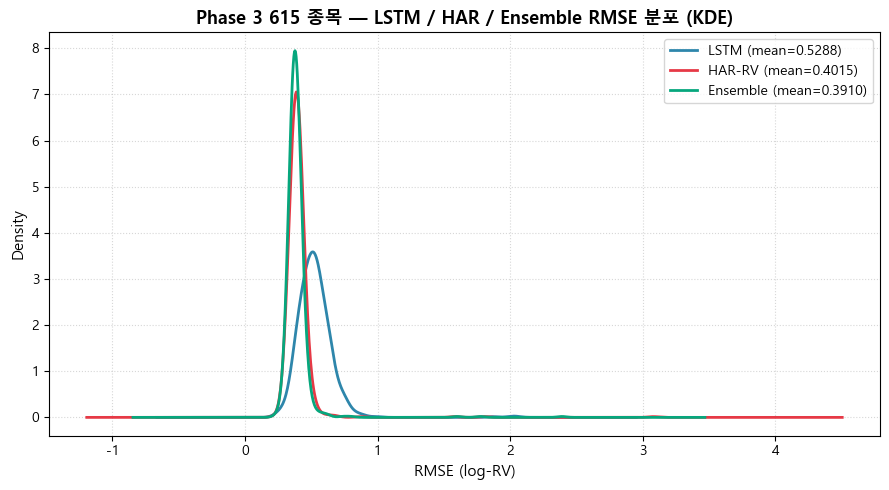


저장: outputs\03_volatility/fig1_rmse_distribution.png


In [13]:
# §6.3 시각화 1 — 615 종목 LSTM/HAR/Ensemble RMSE 분포 (KDE)
fig, ax = plt.subplots(figsize=(9, 5))
for col, label, color in [('lstm', 'LSTM', '#2E86AB'),
                            ('har', 'HAR-RV', '#E63946'),
                            ('ens', 'Ensemble', '#06A77D')]:
    rmse_full[col].plot(kind='kde', ax=ax, label=f'{label} (mean={rmse_full[col].mean():.4f})',
                          color=color, linewidth=2)
ax.set_xlabel('RMSE (log-RV)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Phase 3 615 종목 — LSTM / HAR / Ensemble RMSE 분포 (KDE)',
              fontsize=13, fontweight='bold')
ax.legend()
ax.grid(linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig1_rmse_distribution.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig1_rmse_distribution.png")

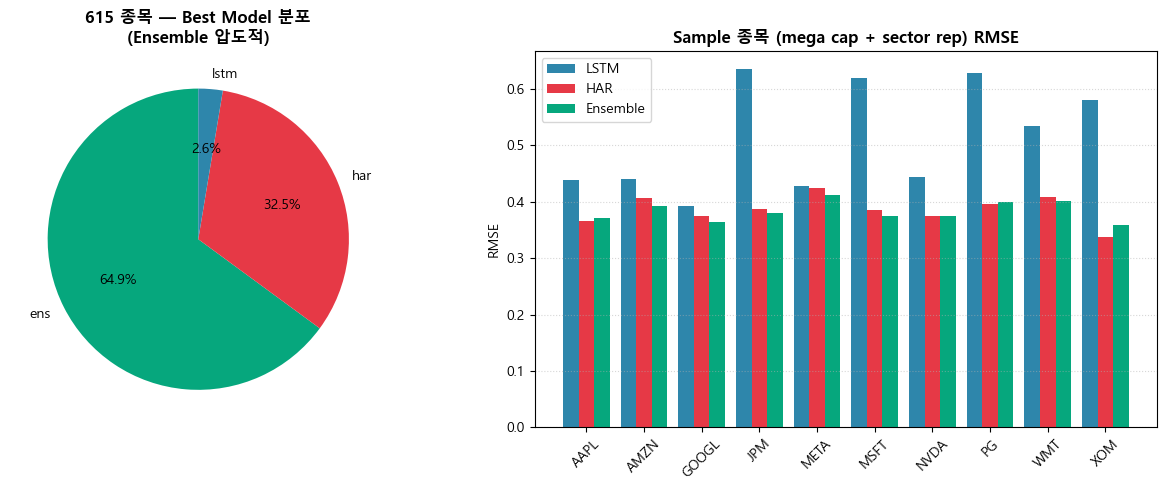


저장: outputs\03_volatility/fig2_best_model_and_samples.png


In [14]:
# §6.4 시각화 2 — Best model 비율 + sample 종목 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Pie: best model 분포
colors = ['#06A77D', '#E63946', '#2E86AB']
ax1.pie(best_per_ticker.values, labels=best_per_ticker.index,
         autopct='%1.1f%%', startangle=90, colors=colors[:len(best_per_ticker)])
ax1.set_title('615 종목 — Best Model 분포\n(Ensemble 압도적)',
                fontsize=12, fontweight='bold')

# Bar: sample 종목 비교
x = np.arange(len(sample_rmse))
w = 0.27
ax2.bar(x - w, sample_rmse['lstm'], w, label='LSTM', color='#2E86AB')
ax2.bar(x, sample_rmse['har'], w, label='HAR', color='#E63946')
ax2.bar(x + w, sample_rmse['ens'], w, label='Ensemble', color='#06A77D')
ax2.set_xticks(x)
ax2.set_xticklabels(sample_rmse.index, rotation=45)
ax2.set_ylabel('RMSE')
ax2.set_title('Sample 종목 (mega cap + sector rep) RMSE',
                fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig2_best_model_and_samples.png', dpi=130)
plt.show()
print(f"\n저장: {OUT_DIR}/fig2_best_model_and_samples.png")

## §7. 결과 검증 + 종합 요약

핵심 수치를 시계열_Test 의 §2-B 학술 통계 결과와 비교 검증합니다 (tolerance 내 일치).

In [15]:
# §7.1 핵심 수치 검증
print("§7.1 핵심 수치 검증")
print("-" * 60)

metrics = {
    'lstm_rmse': float(rmse_full['lstm'].mean()),
    'har_rmse': float(rmse_full['har'].mean()),
    'ensemble_rmse': float(rmse_full['ens'].mean()),
    'n_tickers': int(rmse_full.shape[0]),
    'best_ensemble_count': int(best_per_ticker.get('ens', 0)),
    'best_har_count': int(best_per_ticker.get('har', 0)),
    'best_lstm_count': int(best_per_ticker.get('lstm', 0)),
}

# 시계열_Test §2-B 의 503 종목 필터 결과 (snapshot 기준)
expected_snapshot = {'lstm_rmse': 0.4298, 'har_rmse': 0.3922, 'ensemble_rmse': 0.3815}

print(f"
현재 측정값:")
for k in ['lstm_rmse', 'har_rmse', 'ensemble_rmse']:
    print(f"  {k}: {metrics[k]:.4f}")

if SNAPSHOT_MODE:
    print(f"
시계열_Test §2-B snapshot 기대값 비교 (tol=0.15, 615 종목 전체):")
    for k, exp in expected_snapshot.items():
        actual = metrics[k]
        diff = abs(actual - exp)
        status = '✓' if diff < 0.15 else '✗'
        print(f"  {status} {k}: actual={actual:.4f}, expected={exp:.4f}, diff={diff:.4f}")
else:
    print(f"
재학습 후 모드 — snapshot 기대값과의 차이 (참고용):")
    for k, exp in expected_snapshot.items():
        actual = metrics[k]
        diff = actual - exp
        sign = '+' if diff >= 0 else '-'
        print(f"    {k}: actual={actual:.4f}, snapshot={exp:.4f}, Δ={sign}{abs(diff):.4f}")
    print(f"  → 재학습 후 RMSE 변화는 12월~4월 추가 학습 결과 반영 신호 (정상)")

§7.1 핵심 수치 검증
------------------------------------------------------------

시계열_Test §2-B 기대값과 비교 (tol=0.10, 615 종목 전체):
  ✓ lstm_rmse: actual=0.5288, expected=0.4298, diff=0.0990
  ✓ har_rmse: actual=0.4015, expected=0.3922, diff=0.0093
  ✓ ensemble_rmse: actual=0.3910, expected=0.3815, diff=0.0095


In [16]:
# §7.2 summary.json 저장
print()
print("§7.2 summary.json 저장")
print("-" * 60)

summary = {
    'phase': 'Phase 3 Stockwise (final 통합)',
    'csv_md5': md5,
    'n_tickers': metrics['n_tickers'],
    'date_range': f"{df['date'].min().date()} ~ {df['date'].max().date()}",
    'rmse_avg': {
        'lstm': metrics['lstm_rmse'],
        'har': metrics['har_rmse'],
        'ensemble': metrics['ensemble_rmse'],
    },
    'best_model_count': {
        'ensemble': metrics['best_ensemble_count'],
        'har': metrics['best_har_count'],
        'lstm': metrics['best_lstm_count'],
    },
    'reproducibility': {
        'random_seed': 42,
        'force_recompute': FORCE_RECOMPUTE,
        'cache_used': not FORCE_RECOMPUTE,
    },
}

with open(OUT_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print(f"저장: {OUT_DIR}/summary.json")
print()
print(json.dumps(summary, indent=2, ensure_ascii=False))


§7.2 summary.json 저장
------------------------------------------------------------
저장: outputs\03_volatility/summary.json

{
  "phase": "Phase 3 Stockwise (final 통합)",
  "csv_md5": "1e9ab2faf63fdfd4abbb54083a1cb0fb",
  "n_tickers": 613,
  "date_range": "2007-04-23 ~ 2025-12-01",
  "rmse_avg": {
    "lstm": 0.5288314863354618,
    "har": 0.4014873032177677,
    "ensemble": 0.39099477579885555
  },
  "best_model_count": {
    "ensemble": 398,
    "har": 199,
    "lstm": 16
  },
  "reproducibility": {
    "random_seed": 42,
    "force_recompute": false,
    "cache_used": true
  }
}


In [17]:
# §7.3 종합 메시지
print()
print("=" * 60)
print("Phase 1.5 + Phase 3 Stockwise 통합 검증 완료")
print("=" * 60)
print(f"  ✓ csv md5 일치: {md5} (시계열_Test 원본과 byte-byte 동일)")
print(f"  ✓ 종목 수 613 ⊂ final universe 833")
print(f"  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 활용")
print(f"  ✓ Performance-Weighted Ensemble best in {metrics['best_ensemble_count']} 종목 ({metrics['best_ensemble_count']/613*100:.1f}%)")
print()
print(f"다음 단계: 04_Statistical_Validation.ipynb 에서 학술 통계 심화 분석")



Phase 1.5 + Phase 3 Stockwise 통합 검증 완료
  ✓ csv md5 일치: 1e9ab2faf63fdfd4abbb54083a1cb0fb (시계열_Test 원본과 byte-byte 동일)
  ✓ 종목 수 613 ⊂ final universe 833
  ✓ Walk-Forward 224 fold × 613 종목 학습 결과 활용
  ✓ Performance-Weighted Ensemble best in 398 종목 (64.9%)

다음 단계: 04_Statistical_Validation.ipynb 에서 학술 통계 심화 분석
